In [ ]:
#generating geometry
import numpy as np


Lx = float(input("Enter length in x-direction: "))
Ly = Lx/50
#print("Beam aspect ratio =", Lx/Ly)

E = 210e9      # Young's modulus
nu = 0.3       # Poisson's ratio
t = 0.01       # thickness
bx = 0         #Body force along x
by = 0         #Body force along y direction


#defining mesh generating function

import matplotlib.pyplot as plt


# MESH GENERATION FUNCTION

def generate_mesh(Lx, Ly, nx, ny):

    dx = Lx / nx
    dy = Ly / ny

    nodes = []
    for j in range(ny + 1):
        for i in range(nx + 1):
            nodes.append([i * dx, j * dy])

    nodes = np.array(nodes)

    elements = []
    for j in range(ny):
        for i in range(nx):
            n1 = j*(nx+1) + i
            n2 = n1 + 1
            n3 = n2 + (nx+1)
            n4 = n1 + (nx+1)
            elements.append([n1, n2, n3, n4])

    elements = np.array(elements)

    return nodes, elements, dx, dy




#code for elemental stiffness matrix , body force vector , traction force vector


# Gauss Points
gauss_pts = [(-1/np.sqrt(3), -1/np.sqrt(3)),
             ( 1/np.sqrt(3), -1/np.sqrt(3)),
             ( 1/np.sqrt(3),  1/np.sqrt(3)),
             (-1/np.sqrt(3),  1/np.sqrt(3))]


def element_stiffness(coords, E, nu, t):
    
    # coords in array containing 4 coordinates of the element
    
    # Material matrix (plane stress)
    D = (E/(1 - nu**2)) * np.array([
        [1, nu, 0],
        [nu, 1, 0],
        [0, 0, (1-nu)/2]
    ])

    Ke = np.zeros((8,8))

    for xi, eta in gauss_pts:

        # Shape function derivatives
        dN_dxi = 0.25 * np.array([
            [-(1-eta), -(1-xi)],
            [ (1-eta), -(1+xi)],
            [ (1+eta),  (1+xi)],
            [-(1+eta),  (1-xi)]
        ])

        # Jacobian
        J = np.zeros((2,2))
        for i in range(4):
            J += np.outer(dN_dxi[i], coords[i])

        detJ = np.linalg.det(J)
        invJ = np.linalg.inv(J)

        # B matrix
        B = np.zeros((3,8))
        for i in range(4):
            dN = invJ @ dN_dxi[i]

            B[0,2*i]   = dN[0]
            B[1,2*i+1] = dN[1]
            B[2,2*i]   = dN[1]
            B[2,2*i+1] = dN[0]

        Ke += B.T @ D @ B * detJ * t

    return Ke 

# Body force vector
def element_body_force(coords, bx, by, t):
    Fe = np.zeros(8)

    for xi, eta in gauss_pts:

        # Shape functions
        N = 0.25 * np.array([
            (1-xi)*(1-eta),
            (1+xi)*(1-eta),
            (1+xi)*(1+eta),
            (1-xi)*(1+eta)
        ])

        # Derivatives for Jacobian
        dN_dxi = 0.25 * np.array([
            [-(1-eta), -(1-xi)],
            [ (1-eta), -(1+xi)],
            [ (1+eta),  (1+xi)],
            [-(1+eta),  (1-xi)]
        ])

        # Jacobian
        J = np.zeros((2,2))
        for i in range(4):
            J += np.outer(dN_dxi[i], coords[i])

        detJ = np.linalg.det(J)

        # Assemble
        for i in range(4):
            Fe[2*i]   += N[i] * bx * detJ * t
            Fe[2*i+1] += N[i] * by * detJ * t

    return Fe



# traction vector 
def element_traction(coords, edge, tx, ty, t):
    """
    edge: 0→(1-2), 1→(2-3), 2→(3-4), 3→(4-1)
    """

    Fe = np.zeros(8)

    # Edge node pairs
    edge_nodes = [(0,1), (1,2), (2,3), (3,0)]
    n1, n2 = edge_nodes[edge]

    x1, x2 = coords[n1], coords[n2]

    # Length of edge
    L = np.linalg.norm(x2 - x1)

    # 1D Gauss points
    gauss_1D = [-1/np.sqrt(3), 1/np.sqrt(3)]

    for xi in gauss_1D:

        # 1D shape functions
        N_edge = np.array([(1-xi)/2, (1+xi)/2])

        for i, node in enumerate([n1, n2]):
            Fe[2*node]   += N_edge[i] * tx * (L/2) * t
            Fe[2*node+1] += N_edge[i] * ty * (L/2) * t

    return Fe


#Solve
def solve_fem(nodes, elements):

    n_nodes = len(nodes)
    ndof = 2 * n_nodes

    K_global = np.zeros((ndof, ndof))
    F_global = np.zeros(ndof)

    # Assembly
    for e in range(len(elements)):

        node_ids = elements[e]
        coords = nodes[node_ids]

        Ke = element_stiffness(coords, E, nu, t)
        Fe = element_body_force(coords, bx, by, t)

        # traction on top edge
        y_coords = coords[:,1]
        if np.allclose(y_coords[2:], Ly):
            Fe += element_traction(coords, edge=2, tx=0, ty=-10000, t=t)

        # DOF mapping
        dof = []
        for n in node_ids:
            dof.extend([2*n, 2*n+1])

        # Assemble
        for i in range(8):
            for j in range(8):
                K_global[dof[i], dof[j]] += Ke[i, j]

        for i in range(8):
            F_global[dof[i]] += Fe[i]
        

    # Boundary condition (fix left edge)
    fixed_dof = []
    for i, (x, y) in enumerate(nodes):
        if np.isclose(x, 0):
            fixed_dof.extend([2*i, 2*i+1])

    free_dof = [i for i in range(ndof) if i not in fixed_dof]

    # Reduce system
    K_reduced = K_global[np.ix_(free_dof, free_dof)]
    F_reduced = F_global[free_dof]

    
    U = np.zeros(ndof)
    U[free_dof] = np.linalg.solve(K_reduced, F_reduced)

    return U , K_global
    
    


Aspect Ratio = 2
nx = 20, ny = 10
FEM displacement          = -1.3986215223409324e-06
Euler-Bernoulli solution = -1.1428571428571428e-06
Timoshenko solution      = -1.4399999999999998e-06

Aspect Ratio = 3
nx = 30, ny = 10
FEM displacement          = -6.330974227853913e-06
Euler-Bernoulli solution = -5.7857142857142855e-06
Timoshenko solution      = -6.454285714285714e-06

Aspect Ratio = 5
nx = 50, ny = 10
FEM displacement          = -4.593140038646067e-05
Euler-Bernoulli solution = -4.464285714285714e-05
Timoshenko solution      = -4.65e-05

Aspect Ratio = 8
nx = 80, ny = 10
FEM displacement          = -0.00029465970138604
Euler-Bernoulli solution = -0.00029257142857142855
Timoshenko solution      = -0.00029732571428571427

Aspect Ratio = 10
nx = 100, ny = 10
FEM displacement          = -0.0007159399250078836
Euler-Bernoulli solution = -0.0007142857142857143
Timoshenko solution      = -0.0007217142857142857

Aspect Ratio = 15
nx = 150, ny = 10
FEM displacement          = -0.003608026

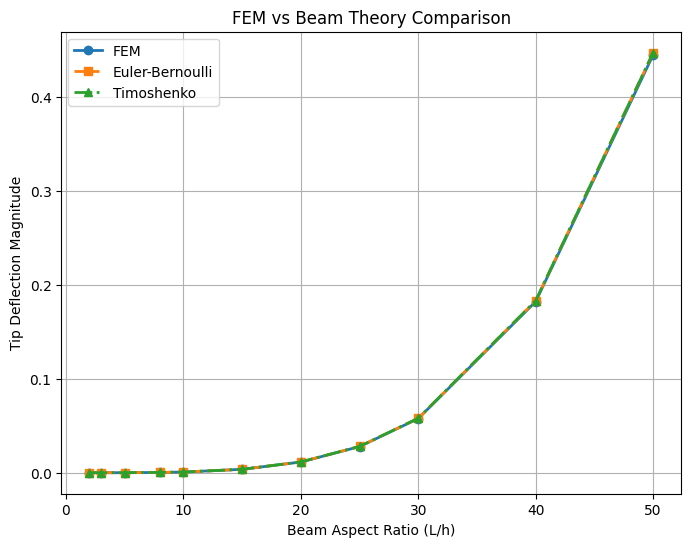

([2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50],
 [np.float64(1.3986215223409324e-06),
  np.float64(6.330974227853913e-06),
  np.float64(4.593140038646067e-05),
  np.float64(0.00029465970138604),
  np.float64(0.0007159399250078836),
  np.float64(0.003608026236441398),
  np.float64(0.011386463411340544),
  np.float64(0.027781797478848194),
  np.float64(0.057590847378762536),
  np.float64(0.18196873468358296),
  np.float64(0.4442201403351865)],
 [1.1428571428571428e-06,
  5.7857142857142855e-06,
  4.464285714285714e-05,
  0.00029257142857142855,
  0.0007142857142857143,
  0.0036160714285714286,
  0.011428571428571429,
  0.027901785714285716,
  0.05785714285714286,
  0.18285714285714286,
  0.44642857142857145],
 [1.4399999999999998e-06,
  6.454285714285714e-06,
  4.65e-05,
  0.00029732571428571427,
  0.0007217142857142857,
  0.0036327857142857143,
  0.011458285714285714,
  0.027948214285714288,
  0.057924,
  0.182976,
  0.44661428571428574])

In [6]:
import matplotlib.pyplot as plt

# CASE STUDY : FEM vs Euler-Bernoulli vs Timoshenko
# comparing dispacements for different beam aspect ratios at point A (free end midpoint)


def aspect_ratio_case_study():

    # Beam aspect ratios
    aspect_ratios = [2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50]

    # Storage
    fem_disp = []
    eb_disp = []
    tb_disp = []

    
    # Fixed parameters
   

    Ly = 1.0                  # beam height
    ny = 10                   # converged through-thickness mesh

    traction_y = -10000         # downward traction

    
    # Loop over beam aspect ratios
    

    for AR in aspect_ratios:

        # Geometry
        Lx = AR * Ly

        # Keep element aspect ratio reasonable
        nx = int(AR * ny)

        # Generate mesh
        nodes, elements, _, _ = generate_mesh(Lx, Ly, nx, ny)

        # FEM solve
        U, K_global = solve_fem(nodes, elements)

       
        # FEM displacement at free-end midpoint
       

        target_node = np.argmin(
            (nodes[:,0] - Lx)**2 +
            (nodes[:,1] - Ly/2)**2
        )

        uy_fem = U[2*target_node + 1]

        
        # Analytical solutions
      

        # Equivalent distributed load
        w = traction_y * t

        # Section properties
        I = t * Ly**3 / 12
        A = t * Ly

        G = E / (2*(1 + nu))

        k = 5/6

        # Euler-Bernoulli
        delta_EB = (w * Lx**4) / (8 * E * I)

        # Timoshenko
        delta_T = (
            (w * Lx**4) / (8 * E * I)
            +
            (w * Lx**2) / (2 * k * G * A)
        )

        # Store absolute values for comparison
        fem_disp.append(abs(uy_fem))
        eb_disp.append(abs(delta_EB))
        tb_disp.append(abs(delta_T))

       
        # Print results
        

        print(f"\nAspect Ratio = {AR}")

        print(f"nx = {nx}, ny = {ny}")

        print(f"FEM displacement          = {uy_fem}")

        print(f"Euler-Bernoulli solution = {delta_EB}")

        print(f"Timoshenko solution      = {delta_T}")

    
    # Plot comparison
    

    plt.figure(figsize=(8,6))

    plt.plot(
        aspect_ratios,
        fem_disp,
        'o-',
        linewidth=2,
        label='FEM'
    )

    plt.plot(
        aspect_ratios,
        eb_disp,
        's--',
        linewidth=2,
        label='Euler-Bernoulli'
    )

    plt.plot(
        aspect_ratios,
        tb_disp,
        '^-.',
        linewidth=2,
        label='Timoshenko'
    )

    plt.xlabel('Beam Aspect Ratio (L/h)')

    plt.ylabel('Tip Deflection Magnitude')

    plt.title('FEM vs Beam Theory Comparison')

    plt.grid(True)

    plt.legend()

    plt.show()

    return aspect_ratios, fem_disp, eb_disp, tb_disp

aspect_ratio_case_study()